### 04. 레이어 합성·통합지수 (P3)

Layer 1·Layer 3·CDRI의 산출물과 검증 결과를 확인한다. 6절에서는 기존 CDRI를 XAI로 분해한다.
수식과 선택 근거는 `docs/METHODOLOGY.md`, 설명 분석은 `docs/XAI.md`에 있다.

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import layers as L
from src.pipeline.graph import Graph
from src.pipeline.report import node_metrics, node_table

GRAPH = Graph.load()
LAYERS = ROOT / "data/processed/layers"
pd.set_option("display.width", 200)

### P3 노드 상태

승인 대기(`awaiting_approval`)는 실패가 아니다. 사람이 확인해야 하류가 열린다.

In [2]:
node_table(*GRAPH.select(phase='P3'))

,이름,게이트,상태,검증,승인,실패 시,node_id
0,데이터 접근신청 현황,H00,pass,code / human,R1,h00_access_requests,h00_access_requests
1,강수량 수집 확인,H00,pass,code / human,-,h00_collect_rainfall,h00_collect_rainfall
2,하천수위 수집 확인,H00,pass,code / human,-,h00_collect_river,h00_collect_river
3,펌프장·하천 목록 수집 확인,H00,pass,code / human,-,h00_collect_small_tables,h00_collect_small_tables
4,SGIS 인구 통계·경계 수집 확인,H00,pass,code / human,-,h00_collect_sgis,h00_collect_sgis
5,토지피복·DEM 수집 확인,H00,pass,code / human,-,h00_collect_geo,h00_collect_geo
6,강수량 원본 검증,H01,pass,code / code / human,R1,h00_collect_rainfall,h01_contract_rainfall
7,하천수위 원본 검증,H01,pass,code / code / human,R1,h00_collect_river,h01_contract_river
8,펌프장·하천 목록 원본 검증,H01,pass,code / code / human,R1,h00_collect_small_tables,h01_contract_small_tables
9,SGIS 인구 통계·경계 원본 검증,H01,pass,code / code / human,R1,h00_collect_sgis,h01_contract_sgis


## 1. Layer 1 — 기후노출 × 도시민감도

국토부 「도시 기후변화 재해취약성분석 지침」 구조다. 두 축을 각각 z-score 합산한 뒤
Jenks 4등급으로 나누고, 두 등급의 합으로 취약성 I~IV 를 준다.

In [3]:
m1 = node_metrics("h06_layer1_flood")
print("격자", f"{m1['n_grid']:,}", "| 순위대상", f"{m1['n_universe']:,}")
pd.DataFrame(m1["class_counts"], index=["전체"]).T.rename(columns={"전체": "격자 수"})

격자 75,400 | 순위대상 10,202


,격자 수
I,4705
II,7897
III,33995
IV,28803


### 1-1. 강수 보간 — 지수 p 를 교차검증으로 고른 근거

IDW 의 거리 지수 $p$ 를 임의로 정하지 않고, 지점을 하나씩 빼고 나머지로 예측해
오차(RMSE)가 가장 작은 값을 골랐다. 변수마다 다른 $p$ 가 뽑힌다.

In [4]:
rows = []
for name, d in m1["idw"]["by_variable"].items():
    row = {"변수": name, "지점수": d["n_stations"], "선택 p": d["power"],
           "지점평균": d["station_mean"], "격자평균": d["grid_mean"],
           "반경밖 대체": d["n_nearest_fallback"]}
    row.update({f"RMSE p={k}": v for k, v in d["loocv_rmse"].items()})
    rows.append(row)
pd.DataFrame(rows)

,변수,지점수,선택 p,지점평균,격자평균,반경밖 대체,RMSE p=1.0,RMSE p=2.0,RMSE p=3.0
0,rain_annual_max_1h,29,1.0,40.803,40.330,514,4.0291,4.0695,4.2107
1,rain_hours_over_30mm,29,1.0,2.176,2.119,514,0.4740,0.4822,0.5012
2,rain_top5_3h,29,3.0,118.480,116.732,514,10.4254,9.4224,9.1525
3,rain_top5_24h,29,2.0,252.568,250.786,514,17.2311,16.7285,17.1753


### 1-2. 민감도 변수의 부호

부호는 계산 **전에** 물리적 근거로 고정했다. 결과를 보고 바꾸지 않는다.
`-1` 은 값이 작을수록 취약하다는 뜻이다(저지대·완경사).

In [5]:
from src.stages.h06_layers import EXPOSURE_SPEC, SENSITIVITY_SPEC

pd.DataFrame([
    {"축": "기후노출" if k in EXPOSURE_SPEC else "도시민감도", "변수": k, "부호": v,
     "z 평균": d["z_mean"], "z 표준편차": d["z_std"]}
    for group in ("exposure", "sensitivity")
    for k, d in m1["composite"][group].items()
    for v in [d["sign"]]
])

,축,변수,부호,z 평균,z 표준편차
0,기후노출,rain_annual_max_1h,1,0.0,1.0
1,기후노출,rain_hours_over_30mm,1,-0.0,1.0
2,기후노출,rain_top5_3h,1,-0.0,1.0
3,기후노출,rain_top5_24h,1,-0.0,1.0
4,도시민감도,rel_elev_m,-1,0.0,1.0
5,도시민감도,slope_deg,-1,0.0,1.0
6,도시민감도,twi,1,-0.0,1.0
7,도시민감도,impervious_frac,1,0.0,1.0
8,도시민감도,river_proximity,1,-0.0,1.0
9,도시민감도,culvert_proximity,1,-0.0,1.0


### 1-3. Jenks 등급 경계와 취약성 매트릭스

Jenks 는 급간 내부 편차제곱합을 최소화하는 경계를 찾는다. 구현이 맞는지는
작은 표본에서 완전탐색 최적해와 대조해 확인했다(`tests/test_layers.py`).

In [6]:
print("노출 등급 경계   :", m1["jenks_breaks"]["exposure"])
print("민감도 등급 경계 :", m1["jenks_breaks"]["sensitivity"])
print()
matrix = pd.DataFrame(
    [[L.ROMAN[L.VULNERABILITY_MATRIX[e + s]] for s in range(1, 5)] for e in range(1, 5)],
    index=[f"노출 {i}등급" for i in range(1, 5)],
    columns=[f"민감도 {j}등급" for j in range(1, 5)],
)
print("취약성 매트릭스 (I 이 가장 취약)")
matrix

노출 등급 경계   : [-2.1485, 0.8003, 3.7842, 8.6334]
민감도 등급 경계 : [-2.0589, 2.244, 7.9783, 26.979]

취약성 매트릭스 (I 이 가장 취약)


,민감도 1등급,민감도 2등급,민감도 3등급,민감도 4등급
노출 1등급,IV,IV,III,III
노출 2등급,IV,III,III,II
노출 3등급,III,III,II,I
노출 4등급,III,II,I,I


### 1-4. 강건성 — 하천 근접·침수예상도를 빼도 순위가 유지되는가

홍재주 외(2015)가 지적한 "하천 인접도에 따른 I등급 과다"와 예상도 의존을 확인한다.
두 변수를 빼고 다시 계산해도 순위 상관이 높으면 특정 변수에 끌려가지 않는다는 뜻이다.

In [7]:
es = m1["exclusion_sensitivity"]
print("제외 변수 :", es["excluded"])
print("순위 상관 :", es["spearman_rho_universe"])
print()
print("검증 상태")
print("  사례지 face-validity :", m1["case_study"])
print("  침수흔적 라벨        :", m1.get("label_available"), "|", m1.get("label_note", ""))

제외 변수 : ['river_proximity', 'culvert_proximity', 'flood_l210_100_depth_m']
순위 상관 : 0.9043

검증 상태
  사례지 face-validity : {'available': True, 'mapping': {'양덕동': ['양덕1동', '양덕2동'], '봉암동': ['봉암동'], '팔용동': ['팔룡동']}, 'unmatched_legal_dong': ['명서동', '사화동'], 'dong_found': ['봉암동', '양덕1동', '양덕2동', '팔룡동'], 'dong_missing': [], 'n_grid': 428, 'high_grade_share': 0.6098, 'base_rate': 0.3747, 'lift': 1.627, 'lift_min': 1.5, 'note': '선행연구 사례지는 독립 성능검증이 아니라 face-validity 점검이다 (하네스 §7)'}
  침수흔적 라벨        : True | 합산 AUC 는 기준을 넘었으나 2006, 2025 사상은 기준 미달이다. 성능을 서술할 때 사상별 표(trace.by_event)를 함께 싣는다


## 2. Layer 3 — 노출·취약성·대응역량

노출은 **수**, 취약성은 **비율**로 나눈다. 같은 사람을 두 번 세지 않기 위해서다.

In [8]:
m3 = node_metrics("h06_layer3_vuln")
print("연령 코드북 :", m3["elderly"]["age_codebook"])
print("검증 방법   :", m3["elderly"]["codebook_verified"])
print()
pd.Series({
    "집계구 수": m3["elderly"]["n_aggregation_units"],
    "집계구 조인율(순위대상)": m3["elderly"]["join_rate_universe"],
    "시 전체 65+ 비율": m3["elderly"]["city_elderly_share"],
    "격자 인구가중 65+ 비율": m3["elderly"]["grid_pop_weighted_universe"],
    "격자 단순평균 65+ 비율": m3["elderly"]["grid_unweighted_mean_universe"],
}).to_frame("값")

연령 코드북 : in_age 5세 계급, 65세 이상 = in_age_014 이후
검증 방법   : 노령화지수(to_in_004) 항등식 대조 — src/data/sgis.py 주석



,값
집계구 수,2118.0000
집계구 조인율(순위대상),1.0000
시 전체 65+ 비율,0.1841
격자 인구가중 65+ 비율,0.1908
격자 단순평균 65+ 비율,0.3173


**단순평균(0.32)이 시 전체(0.18)보다 훨씬 높은 이유.** 면적이 넓은 농촌 집계구가 격자를 많이
차지하기 때문이다. 시 전체와 비교할 수 있는 값은 **인구가중 평균**(0.19)이고, 그것이 맞는다.
집계구 하나가 최대 몇 개 격자에 같은 값을 주는지도 함께 기록한다 — 배분 불확실성이다.

In [9]:
print("집계구당 순위대상 격자 수 :", m3["elderly"]["grids_per_aggregation_unit"])
print()
print("대응역량")
cap = m3["capacity"]
pd.Series({
    "대피장소": cap["by_kind"]["shelter"], "방재기관": cap["by_kind"]["facility"],
    "대피소 중앙거리(m)": cap["shelter_dist_median_universe"],
    "방재기관 중앙거리(m)": cap["facility_dist_median_universe"],
    "부족도 평균": cap["capacity_deficit_mean_universe"],
}).to_frame("값")

집계구당 순위대상 격자 수 : {'median': 2.0, 'max': 106, 'note': '집계구 하나가 격자 여러 개에 같은 비율을 준다 — 배분 불확실성 (ANALYSIS_PLAN §4)'}

대응역량


,값
대피장소,444.0000
방재기관,516.0000
대피소 중앙거리(m),360.4000
방재기관 중앙거리(m),348.0000
부족도 평균,0.2361


**취약성 V 에서 빠진 변수.** 자료를 아직 못 구했다. 보고서 한계에 그대로 쓴다.

In [10]:
pd.Series(m3['missing_variables']).to_frame('사유')

,사유
one_person_household_ratio,SGIS 1인가구 미보유 (100m·집계구 모두)
old_building_ratio,GIS건물통합정보 SHP 미확보 (V-World 키 필요)
basement_building_count,건축물대장 지하층수 미확보 (건축HUB 키 필요)


## 3. CDRI 통합

$$\text{CDRI}_i = \prod_{k \in \{H,E,V,D\}} (X'_{ik})^{w_k}, \qquad
X' = 0.05 + 0.95\cdot\text{minmax}(X)$$

하한을 0 이 아니라 0.05 로 두는 이유는, minmax 로 0 이 된 요소 하나 때문에 기하평균 전체가
0 이 되어 순위 정보가 사라지는 것을 막기 위해서다.

In [11]:
m7 = node_metrics("h07_cdri")
print("기본 산식      :", m7["primary_formula"])
print("Layer 2 포함   :", m7["layer2_included_in_primary"], "|", m7["layer2_reason"])
print()
pd.DataFrame(m7["weights"], index=["H", "E", "V", "D"]).T

기본 산식      : geometric_equal
Layer 2 포함   : False | 관로 비공개로 검증 불가 — docs/decisions/001-layer2-design.md



,H,E,V,D
equal,0.2500,0.2500,0.2500,0.2500
entropy,0.0856,0.6385,0.1248,0.1511


**엔트로피 가중은 인구(E)에 64% 를 몰아준다.** 인구 분포의 왜도가 크기 때문이다.
이론 틀(네 요소가 모두 필요조건)과 어긋나므로 기본 산식으로 쓰지 않고 민감도 비교용으로만 쓴다.

### 3-1. 민감도 — 이 연구의 핵심 발견

In [12]:
pd.DataFrame(m7["variants"])

,variant,spearman_rho_vs_primary,top20_overlap,top20_overlap_pct
0,geometric_equal,1.0000,20,1.00
1,additive_equal,0.8781,10,0.50
2,geometric_entropy,0.8477,10,0.50
3,additive_entropy,0.9249,9,0.45


In [13]:
rb = m7["robustness"]
print("중위 순위상관 :", rb["median_spearman_rho"], f"(기준 {rb['min_spearman_required']})")
print("TOP20 최소중첩:", rb["min_top20_overlap"], f"(기준 {rb['min_overlap_required']})")
print("미달 항목     :", rb["unmet"])
print()
print("→ ranking_mode =", m7["ranking_mode"])
print("  ", m7["ranking_mode_note"])
print("  강건 공통집합:", m7["robust_core"])

중위 순위상관 : 0.8781 (기준 0.8)
TOP20 최소중첩: 9 (기준 14)
미달 항목     : ['TOP 20 최소 중첩 9 < 14']

→ ranking_mode = tier
   정밀 순위를 주장하지 않는다. 위험군(tier)과 강건 공통집합으로만 보고한다 — 하네스 H07 분기
  강건 공통집합: {'n': 8, 'note': '가중치·집계형 변형 4개 모두의 TOP 20 에 공통으로 드는 격자'}


전체 순위 경향은 잘 유지되는데($\rho \ge 0.85$) 최상위 20곳은 절반만 겹친다.
상위권은 값 차이가 미세해 산식을 조금만 바꿔도 순서가 뒤집히기 때문이다.

하네스 H07 은 이 경우 **"정밀 순위 대신 위험군 모드로 보고, 재튜닝 금지"** 라고 미리 정했다.
그래서 기준을 낮추지 않고 산출물의 성격을 바꿨다.

### 3-2. 그 밖의 민감도

In [14]:
print("해상도(MAUP) :", m7["maup"])
print()
g = m7["grade_system"]
print("등급 본안 :", g["scheme"], "—", g["scheme_reason"])
print("가중 kappa:", g["weighted_kappa"])
print()
pd.DataFrame({
    "Jenks(본안)": {k: v["n"] for k, v in g["raw"].items()},
    "규칙 적용 후": {k: v["n"] for k, v in g["final"].items()},
    "고정 백분위": {k: v["n"] for k, v in g["percentile_for_comparison"].items()},
    "Balica": {k: v["n"] for k, v in g["balica_for_comparison"].items()},
}).reindex(["R5", "R4", "R3", "R2", "R1"])

해상도(MAUP) : {'resolution_m': 500, 'n_blocks': 1605, 'spearman_rho_mean_vs_max': 0.8812, 'note': '500m 블록의 평균과 최대 재집계 순위 비교'}

등급 본안 : calibration — 침수흔적 양성 격자 299개 ≥ 100 이고 시간 분할 가능
가중 kappa: {'jenks_vs_balica': 0.7199, 'jenks_vs_percentile': 0.8104, 'balica_vs_percentile': 0.4875, 'note': '2차 가중 kappa. Landis & Koch(1977) 기준 0.61~0.80 substantial', 'calibration_vs_jenks': 0.8015, 'calibration_vs_balica': 0.4727}



,Jenks(본안),규칙 적용 후,고정 백분위,Balica
R5,76,130,205,226
R4,944,947,816,1746
R3,2041,2047,2040,5831
R2,3029,2989,3060,2398
R1,4112,4089,4081,1


### 3-3. 주 원인을 백분위로 정한 이유

가법형 구성비의 최댓값을 쓰면 분포가 치우친 요소(인구)가 거의 항상 이겨서 조치가 한쪽으로 쏠린다.
그래서 ANALYSIS_PLAN §5 대로 **구성요소 백분위가 가장 높은 것**을 주 원인으로 쓴다.

In [15]:
print(m7["cdri_summary"]["primary_cause_rule"])
print()
pd.Series(m7["cdri_summary"]["primary_cause_counts"]).to_frame("격자 수")

구성요소 백분위가 가장 높은 것 (ANALYSIS_PLAN §5)



,격자 수
V,2945
E,2778
H,2278
D,2201


### 3-4. 구성요소 상관 — 중복 투입이 없는지 확인

In [16]:
cdri = gpd.read_file(LAYERS / "cdri.gpkg", layer="cdri")
cdri[["H_scaled", "E_scaled", "V_scaled", "D_scaled", "cdri"]].corr().round(3)

,H_scaled,E_scaled,V_scaled,D_scaled,cdri
H_scaled,1.000,0.348,-0.401,-0.095,0.548
E_scaled,0.348,1.000,-0.519,-0.178,0.729
V_scaled,-0.401,-0.519,1.000,0.092,-0.142
D_scaled,-0.095,-0.178,0.092,1.000,0.134
cdri,0.548,0.729,-0.142,0.134,1.000


## 4. 침수흔적 외적 검증 — 실제로 잠겼던 곳과 대조

여기부터가 "지도를 만들었다"와 "실제로 맞췄다"를 가르는 부분이다.
흔적도는 Layer 1 의 **입력이 아니다**. 산출이 끝난 뒤 채점에만 쓴다 (ANALYSIS_PLAN §2-3).


In [17]:
trace = m1["trace"]

print("자료원별 건수 :", trace["rows_per_file"])
print("중복 도형 제거:", trace["duplicate_geometries_dropped"], "건 (L100 침수심 = L110 침수위)")
print("최종 흔적     :", trace["n_traces"], "건 /", trace["area_km2"], "km2")
print("사상          :", trace["n_events"], "건 /", trace["n_years"], "개 연도", trace["years"])
print("일자 범위     :", trace["date_range"])
print()
print("양성 격자     :", trace["n_labelled_grid"], "(순위대상", trace["n_labelled_in_universe"], ")")
print("판정 기준     :", trace["min_positive_required"], "칸 →",
      "충족" if trace["label_sufficient"] else "미달")

자료원별 건수 : {'L100_침수심.shp': 19, 'L110_침수위.shp': 18, 'changwon_flood_traces.gpkg': 125}
중복 도형 제거: 17 건 (L100 침수심 = L110 침수위)
최종 흔적     : 145 건 / 4.619 km2
사상          : 12 건 / 6 개 연도 ['2006', '2012', '2014', '2016', '2019', '2025']
일자 범위     : ['2006-07-10', '2025-07-19']

양성 격자     : 642 (순위대상 299 )
판정 기준     : 30 칸 → 충족


### 4-1. 점추정은 두 기준을 넘었다

기준은 자료를 보기 **전에** `config/config.yaml` 에 박아 둔 값이다. 사후에 낮추지 않는다.
**다만 이 표만 보고 '검증 통과'라고 쓰면 안 된다** — 4-1-1·4-1-2 가 그 이유다.


In [18]:
top_all, top_uni = trace["top20pct_all_grid"], trace["top20pct_universe"]
pd.DataFrame({
    "전체 격자": [trace["auc_all_grid"], top_all["capture_rate"], top_all["lift"], top_all["base_rate"]],
    "순위대상": [trace["auc_universe"], top_uni["capture_rate"], top_uni["lift"], top_uni["base_rate"]],
    "기준": [trace["auc_min"], trace["capture_min"], "—", "—"],
}, index=["ROC-AUC", "상위 20% 포착률", "lift", "기저 발생률"])

,전체 격자,순위대상,기준
ROC-AUC,0.7504,0.7134,0.7
상위 20% 포착률,0.5436,0.4415,0.5
lift,2.7180,2.2080,—
기저 발생률,0.0085,0.0293,—


**읽는 법.** 상위 20% 격자가 실제 침수의 54.4%를 담았다. 무작위로 20%를 고르면 20%만
담긴다. 즉 2.72배 효율이다.

순위대상만 보면 낮아진다(AUC 0.713). 인구·주택이 있는 칸끼리는 서로 비슷해 변별이 어렵기
때문이다. **두 값을 모두 보고한다** — 전체 기준만 쓰면 "산지를 빼서 얻은 점수"라는 지적을
받고, 순위대상만 쓰면 지수가 저지대를 골라내는 능력을 과소평가한다.


### 4-1-1. 격자 642칸은 표본 642개가 아니다 — 침수 1건 = 1표로 다시 센다

침수흔적 폴리곤 하나가 격자 수십 칸을 덮는다. 붙어 있는 격자는 **같은 침수 한 건**이다.
격자를 그대로 세면 두 가지가 틀어진다 — 신뢰구간이 좁아지고, 큰 덩어리 몇 개가 점수를 좌우한다.

그래서 (1) 재표본을 **덩어리 단위**로 하고, (2) AUC 를 **침수 한 건마다 1표**로도 센다.


In [19]:
es, ci = trace["effective_sample"], trace["auc_ci"]
print(f"양성 격자 {es['n_positive_grid']}칸 → 독립 침수 {es['n_cluster']}건 "
      f"(덩어리 크기 중앙 {es['cluster_size_median']}칸, 최대 {es['cluster_size_max']}칸)")
print()
print(f"격자마다 1표   AUC {ci['auc']}  95% {ci['ci95']}")
print(f"침수마다 1표   AUC {ci['auc_cluster_weighted']}  95% {ci['ci95_cluster_weighted']}")
print(f"게이트 기준 {trace['auc_min']} 이 격자 가중 구간 안에 있는가 →",
      ci["ci95"][0] <= trace["auc_min"] <= ci["ci95"][1])

양성 격자 642칸 → 독립 침수 46건 (덩어리 크기 중앙 3칸, 최대 86칸)

격자마다 1표   AUC 0.7504  95% [0.633, 0.8625]
침수마다 1표   AUC 0.7044  95% [0.6294, 0.7754]
게이트 기준 0.7 이 격자 가중 구간 안에 있는가 → True


게이트(격자 가중 점추정 ≥ 0.70)는 사전에 정한 대로 통과했다. 다만 **구간 안에 기준이
들어 있으므로 "0.70 을 확실히 넘었다"고는 쓰지 않는다.** 침수마다 1표로 세면 0.704 로
기준에 겨우 걸친다.

참고로 격자 단위로 재표본하면 구간 폭이 0.035 로, 덩어리 단위(0.23)보다 6.5배 좁게 나온다.

### 4-1-2. 시 침수예상도에 무엇을 더했나 — 짝지은 비교

시 침수예상도는 Layer 1 의 **입력**이다. 예상도 단독 점수와 나란히 놓아 우리 기여를 분리한다.


In [20]:
iv = trace["incremental_value"]
names = {"city_flood_map_only": "시 침수예상도 단독",
         "layer1": "Layer 1 현행",
         "layer1_without_flood_map": "Layer 1 − 예상도"}
pd.DataFrame({names[k]: v for k, v in iv["scores"].items()}).T.rename(columns={
    "auc": "AUC (격자 1표)", "auc_cluster_weighted": "AUC (침수 1표)", "top20pct_capture": "상위20% 포착률"})

,AUC (격자 1표),AUC (침수 1표),상위20% 포착률
시 침수예상도 단독,0.7094,0.6239,0.5202
Layer 1 현행,0.7504,0.7044,0.5436
Layer 1 − 예상도,0.7339,0.6972,0.5047


**두 점수의 신뢰구간이 겹친다고 "차이 없음"이라고 하면 틀린다.** 같은 침수들로 채점한
두 점수는 강하게 상관돼 있어서, 차이의 불확실성은 각 구간보다 훨씬 작다.
같은 재표본에서 **차이를 직접** 계산한다.


In [21]:
pair = iv["paired"]
pd.DataFrame({
    names[k]: {
        "차이 (격자 1표)": v["diff"], "95% 구간": v["diff_ci95"], "나을 확률": v["prob_better"],
        "차이 (침수 1표)": v["diff_cluster_weighted"], "95% 구간 ": v["diff_ci95_cluster_weighted"],
        "나을 확률 ": v["prob_better_cluster_weighted"],
    }
    for k, v in pair.items() if isinstance(v, dict)
}).T

,차이 (격자 1표),95% 구간,나을 확률,차이 (침수 1표),95% 구간,나을 확률
Layer 1 현행,0.041,"[-0.0031, 0.0986]",0.964,0.0805,"[0.0239, 0.1386]",0.999
Layer 1 − 예상도,0.0245,"[-0.0275, 0.0871]",0.809,0.0734,"[0.0125, 0.1354]",0.994


**침수마다 1표로 세면 우리 지수가 시 예상도보다 +0.081 높고, 95% 구간 [+0.024, +0.139] 가
0 을 넘는다(나을 확률 99.9%).** 예상도 변수를 뺀 지수도 +0.073 [+0.013, +0.135] 로 마찬가지다.

격자마다 1표로 세면 +0.041 [−0.003, +0.099] 로 경계선이다. 차이의 이유는 예상도 **안쪽**의
큰 침수 덩어리 몇 개(2016·2019 시가지)를 예상도가 잘 맞혀서, 격자 수로 세면 그 몇 건이
점수를 끌어올리기 때문이다. **두 가중을 항상 함께 보고한다** — 유리한 쪽만 고르지 않는다.

### 4-1-3. 예상도가 아무것도 말해주지 않는 곳에서 우리 지수는


In [22]:
rows = {}
for key, label in (("outside_city_map", "예상도 밖 (침수심 0)"), ("inside_city_map", "예상도 안 (침수심 > 0)")):
    st = iv["strata"][key]
    rows[label] = {"격자": st["n_grid"], "양성 격자": st["n_positive_grid"], "독립 침수": st["n_cluster"],
                   **{names[k]: v for k, v in (st["auc"] or {}).items()}}
pd.DataFrame(rows).T

,격자,양성 격자,독립 침수,시 침수예상도 단독,Layer 1 현행,Layer 1 − 예상도
예상도 밖 (침수심 0),66067.0,308.0,37.0,0.5000,0.6341,0.6341
예상도 안 (침수심 > 0),9333.0,334.0,20.0,0.6518,0.5877,0.5364


**예상도 밖**(창원 격자의 88%)에서는 예상도 점수가 전부 0 이라 AUC 가 0.5 로 고정된다.
그 구역에서 우리 지수는 **0.634** — 이것이 **시 모형과 무관한 우리만의 기여**다.

**예상도 안**에서는 반대다. 예상도 단독(0.652)이 우리 지수(0.588)보다 낫다. 예상 침수심이
민감도 8변수 중 하나로 동일가중되면서 그 신호가 희석된 것이다. 이것은 개선 여지로 기록한다 —
**다만 검증 결과를 보고 가중치를 고치면 재튜닝이 되므로 지금 산식에는 반영하지 않는다.**

**정리.** 우리 지수는 예상도가 없는 곳에서 정보를 더하고, 예상도가 있는 곳에서는 예상도를
약간 흐린다. 합치면 침수마다 1표 기준으로 예상도보다 확실히 낫다.


### 4-2. 창원시 회신분만 사용했을 때의 AUC

회신분만 사용한 격자 가중 AUC는 0.365였고, 자료를 합친 뒤에는 0.750이었다.
산식·가중치를 바꾼 결과가 아니라 평가 표본이 달라진 결과다.
주 성능 근거는 앞 절의 침수 1건 가중 비교(+0.081)이며, 두 표본의 AUC 차이를 개선 폭으로 해석하지 않는다.

In [23]:
diag = trace["diagnosis"]
pd.DataFrame({
    "침수 격자 중앙값": diag["flooded_median"],
    "창원 전체 중앙값": diag["city_median"],
}).rename_axis("변수")

,침수 격자 중앙값,창원 전체 중앙값
변수,,
elev_m,6.310,83.152
slope_deg,0.497,11.351
twi,10.928,7.163
impervious_frac,0.450,0.000
flood_l210_100_frac,0.080,0.000
pump_dist_m,3608.608,5571.945
pop_total,0.000,0.000


회신분의 중앙값은 불투수면 0%, 예상 침수심 0, 펌프장 거리 14.7km였다.
이 요약만으로 낮은 성능을 농경지 탓으로 단정할 수는 없다. 사상별 표본 수와 변수 분포를 함께 확인한다.
적용 범위를 사후에 좁혀 낮은 AUC를 검증 대상에서 제외하지 않는다.

In [24]:
print("시 침수예상도가 덮은 흔적 격자:", diag["n_covered_by_city_flood_map"], "/", trace["n_labelled_grid"])
print()
print("시간 분할 (등급 캘리브레이션과 검증의 순환을 막는 장치)")
for k, v in trace["time_split"].items():
    print(f"  {k:20} {v}")

시 침수예상도가 덮은 흔적 격자: 334 / 642

시간 분할 (등급 캘리브레이션과 검증의 순환을 막는 장치)
  years                ['2006', '2012', '2014', '2016', '2019', '2025']
  calibration_years    ['2006', '2012', '2014']
  validation_years     ['2016', '2019', '2025']
  n_cal                440
  n_val                251
  event_columns        ['trace_ev_2006', 'trace_ev_2012', 'trace_ev_2014', 'trace_ev_2016', 'trace_ev_2019', 'trace_ev_2025']
  usable               True
  n_both               49


### 4-3. 사상별로 나눠 보면 성능이 갈린다

합산 AUC 는 큰 사상 하나가 좋으면 나머지가 나빠도 높게 나온다. 사상 하나씩 따로 채점해
성능이 특정 호우에 기대고 있는지 본다. 음성은 **어느 사상에서도 잠기지 않은 격자**로 둔다 —
다른 사상에서 잠긴 칸을 음성으로 세면 맞힌 것을 틀렸다고 채점하게 된다.


In [25]:
pd.DataFrame([
    {
        "사상": r["event_name"],
        "양성 격자": r["n_positive_grid"],
        "AUC": r.get("auc"),
        "상위20% 포착률": r["top20pct"]["capture_rate"] if "auc" in r else None,
        "내수 비율": r["inland_share"],
    }
    for r in trace["by_event"]
], index=[r["event_year"] for r in trace["by_event"]]).rename_axis("연도")

,사상,양성 격자,AUC,상위20% 포착률,내수 비율
연도,,,,,
2006,2006.7.3 제3호 태풍 에위니아로 인한 집,107,0.3894,0.0000,0.000
2012,태풍 산바,206,0.7924,0.5583,0.516
2014,2014년 국지성 집중호우,132,0.7864,0.5076,0.404
2016,"제8호 태풍 ""차바""",170,0.9204,0.9353,0.000
2019,미탁,56,0.9617,0.9821,0.000
2025,2025년 07.19 집중호우,25,0.3671,0.0000,0.900


**포착률 0.000 은 반올림이 아니라 진짜 0이다.** 왜 그런지 점수 분포로 확인한다.


In [26]:
import numpy as np

from src.data import flood_traces as FT

l1 = gpd.read_file(LAYERS / "layer1_flood.gpkg", layer="layer1_flood",
                   columns=["grid_id", "L1"])
traces, _ = FT.load(FT.find_files(ROOT / "data/raw/flood_traces")[0])
cut = float(np.percentile(l1["L1"], 80))       # 상위 20% 경계

rows = []
for year in sorted(traces["event_year"].dropna().unique()):
    labels, _ = FT.label_grid(l1, traces[traces["event_year"] == year], min_overlap=0.10)
    scores = l1.loc[labels, "L1"]
    rows.append({
        "연도": year, "칸": int(labels.sum()),
        "L1 중앙": round(float(scores.median()), 4),
        "L1 최대": round(float(scores.max()), 4),
        "경계 넘는 칸": int((scores > cut).sum()),
        "L1 표준편차": round(float(scores.std()), 4),
    })
print(f"상위 20% 경계 L1 = {cut:.4f}   (창원 전체 L1 표준편차 {l1['L1'].std():.4f})")
pd.DataFrame(rows).set_index("연도")

상위 20% 경계 L1 = 0.4207   (창원 전체 L1 표준편차 0.1236)


,칸,L1 중앙,L1 최대,경계 넘는 칸,L1 표준편차
연도,,,,,
2006,107,0.2827,0.3683,0,0.0266
2012,206,0.4588,0.7249,115,0.1326
2014,132,0.4201,0.7387,65,0.0930
2016,170,0.5760,0.8072,159,0.1049
2019,56,0.6124,0.7249,55,0.0554
2025,25,0.2600,0.3480,0,0.0315


2006년 침수 격자 107칸의 L1 최댓값이 0.3683, 2025년 25칸의 최댓값이 0.3480인데
상위 20% 경계는 0.4188이다. **가장 높은 칸조차 경계에 못 미쳐** 단 한 칸도 못 들어갔다.
두 사상의 격자는 한 구역에 붙어 있어 점수가 거의 같다(L1 표준편차 0.026·0.031,
창원 전체는 0.124).

### 4-4. 무엇이 갈랐나 — 중앙값이 아니라 비율로 본다

처음에는 잠긴 격자의 **중앙값**으로 진단했는데 그 방식이 틀렸다. 불투수면 같은 변수는
0에 몰린 양봉분포라, 절반을 조금 넘는 칸이 0이면 중앙값이 0이 되어 "전부 농경지"처럼
보인다. 실제로는 절반이 시가지일 수 있다. 조건을 만족하는 **칸의 비율**로 다시 낸다.


In [27]:
keys = ["impervious_gt0", "flood_map_gt0", "pump_within_1km", "river_within_200m"]
names = {"impervious_gt0": "불투수면 > 0", "flood_map_gt0": "시 예상도 > 0",
         "pump_within_1km": "펌프 1km 내", "river_within_200m": "하천 200m 내"}

rows = [{"연도": r["event_year"], "AUC": r.get("auc"),
         **{names[k]: r["urbanness"][k] for k in keys}} for r in trace["by_event"]]
rows.append({"연도": "창원 전체", "AUC": None,
             **{names[k]: trace["diagnosis"]["city_urbanness"][k] for k in keys}})
pd.DataFrame(rows).set_index("연도")

,AUC,불투수면 > 0,시 예상도 > 0,펌프 1km 내,하천 200m 내
연도,,,,,
2006,0.3894,0.271,0.000,0.000,0.542
2012,0.7924,0.835,0.592,0.476,0.286
2014,0.7864,0.492,0.273,0.076,0.758
2016,0.9204,0.994,0.971,0.165,0.500
2019,0.9617,1.000,1.000,0.982,0.000
2025,0.3671,0.120,0.000,0.000,0.280
창원 전체,NaN,0.284,0.124,0.044,0.207


2006년 침수 격자의 불투수면 > 0 비율은 27.1%로 창원 전체 28.4%와 비슷하다.
“농경지라서 못 잡았다”는 설명은 이 비교로 뒷받침되지 않는다.

성능이 낮은 두 사상은 예상도 커버리지와 펌프장 1km 내 비율이 모두 0이었다.
2014년은 하천 200m 내 비율이 0.758이고 기록에도 하천범람이 있어, 하천 근접 변수의 역할을
살펴볼 사례다. 다만 이 비교는 기술적 진단이며 변수의 인과효과를 입증하지 않는다.

예상도 밖 전체의 침수 가중 AUC는 0.634다. 따라서 “예상도 밖은 모두 못 잡는다”는 일반화도
맞지 않는다. 전체 비교와 사상별 실패 사례를 함께 보고한다.

In [28]:
spread = trace["event_auc_spread"]
for k, v in spread.items():
    print(f"{k:20} {v}")

n_scored             6
min                  0.3671
max                  0.9617
all_above_min        False
events_below_min     ['2006', '2025']
note                 합산 AUC 는 기준을 넘었으나 사상별로는 갈린다. 미달 사상을 함께 보고하지 않으면 성능을 과대 진술하게 된다


전체 AUC와 함께 사상별 편차를 보고한다. 예상도 안·밖의 분리 평가는 의존성을 확인하는
사후 진단이며, 주 평가의 공간 범위나 산식·가중치를 바꾸는 데 사용하지 않는다.

## 5. 등급 경계 캘리브레이션 — 점수가 아니라 발생률로

Jenks 는 **점수 분포**의 단절만 본다. 결정 003 이 본안으로 고른 3안은 등급 경계를
**관측된 침수 발생률**로 맞춘다. 침수흔적 642격자·6개 사상을 확보해 본안 조건이 충족됐다.

**운영 등급**의 경계는 모든 사상으로 맞춘다. 경계가 실제 위험을 가르는지는
**사상 단위 교차검증(LOEO)** 으로 따로 잰다.


In [29]:
gs = m7["grade_system"]
cal = gs["calibration"]
print("본안 :", gs["scheme"], "—", gs["scheme_reason"])
print("운영 경계 (R1~R4 상한):", [round(b, 4) for b in cal["breaks"]])
print("등급 크기            :", dict(zip(["R1", "R2", "R3", "R4", "R5"], cal["grade_sizes"])))
pd.DataFrame(cal["moves"])

본안 : calibration — 침수흔적 양성 격자 299개 ≥ 100 이고 시간 분할 가능
운영 경계 (R1~R4 상한): [0.306, 0.4327, 0.5864, 0.8372]
등급 크기            : {'R1': 4112, 'R2': 3029, 'R3': 2041, 'R4': 944, 'R5': 76}


,target_percentile,moved_to_percentile,shift_pp,snapped_to_pav_break
0,0.98,0.9926,1.25,True
1,0.90,0.9000,0.00,False
2,0.70,0.7000,0.00,False
3,0.40,0.4031,0.30,True


목표 백분위(98/90/70/40)에서 ±3%p 안에 등온회귀(PAV) 곡선의 단차가 있으면 그리로 옮긴다.

### 5-1. 왜 사상 단위 교차검증인가

처음에는 앞 사상 3개(2006·2012·2014)로 경계를 정하고 뒤 사상 3개로 채점했다.
그런데 검증에 쓰인 침수가 몇 건이었는지 세 보면 판정이 불가능한 수준이었다.


In [30]:
ts = gs["validation"]["time_split"]
print("시간 분할 검증에 쓰인 독립 침수:", ts["bootstrap"]["n_cluster"], "건")
print("등급별                         :", ts["bootstrap"]["clusters_by_grade"])

시간 분할 검증에 쓰인 독립 침수: 12 건
등급별                         : {'R1': 10, 'R2': 8, 'R3': 9, 'R4': 4, 'R5': 1}


R5 는 **침수 1건**이었다. 그 한 건이 다른 곳에서 났다면 R5 lift 는 0 이다.
설계 문서가 미리 정해 둔 대안(CDRI_GRADE_SYSTEM §1③① "사상 수가 부족하면 사상 단위
leave-one-event-out 으로 대체")으로 넘어간다. 사상을 하나씩 빼고 나머지로 경계를 맞춘 뒤
뺀 사상으로 채점하면, **모든 사상이 한 번씩 검증에 쓰여** 검증 침수가 전체로 늘어난다.

가정: 사상들을 서로 바꿔 써도 되는 표본으로 본다. 2019 년 사상으로 정한 경계로 2006 년을
채점하는 일도 생기므로 미래 예측 검증이 아니라 교차검증이다.


In [31]:
lo = gs["validation"]["loeo"]
folds = pd.DataFrame(lo["folds"]).set_index("held_out")
folds["breaks"] = folds["breaks"].astype(str)
print("검증 침수 합계:", lo["n_cluster"], "건   |   폴드 간 경계 폭:", lo["break_range"])
folds

검증 침수 합계: 46 건   |   폴드 간 경계 폭: [0.0042, 0.0, 0.0, 0.0161]


,breaks,n_positive,n_cluster
held_out,,,
2006,"[0.306, 0.4327, 0.5864, 0.8372]",10,5
2012,"[0.3052, 0.4327, 0.5864, 0.8372]",105,15
2014,"[0.3018, 0.4327, 0.5864, 0.8533]",47,14
2016,"[0.3052, 0.4327, 0.5864, 0.8412]",132,6
2019,"[0.306, 0.4327, 0.5864, 0.8372]",46,4
2025,"[0.306, 0.4327, 0.5864, 0.8372]",2,2


**어느 사상을 빼도 경계가 거의 같다** (폴드 간 폭 최대 0.016, 가운데 두 경계는 0).
경계 규칙이 특정 사상에 끌려다니지 않는다는 뜻이며, 이것은 표본 크기와 무관하게 확인되는 성질이다.

### 5-2. 교차검증 채점


In [32]:
tbl = pd.DataFrame(lo["rows"]).set_index("grade")
tbl["아래 등급 대비"] = [None] + lo["adjacent_ratios"]
print("등급별 독립 침수 수:", lo["clusters_by_grade"])
tbl.rename(columns={"n": "격자·폴드", "positives": "양성", "incidence": "발생률"})

등급별 독립 침수 수: {'R1': 35, 'R2': 23, 'R3': 16, 'R4': 8, 'R5': 3}


,격자·폴드,양성,발생률,lift,아래 등급 대비
grade,,,,,
1,24459,115,0.00470,0.842,NaN
2,18387,100,0.00544,0.973,1.157
3,12246,64,0.00523,0.935,0.961
4,5687,44,0.00774,1.385,1.480
5,433,19,0.04388,7.854,5.669


In [33]:
boot = lo["bootstrap"]
print(f"추세 기울기       {boot['trend_slope']}  95% {boot['trend_slope_ci95']}")
print(f"기울기 ≤ 0 확률   {boot['p_slope_nonpositive']}   (기준 < {0.01})")
print(f"5등급 모두 단조   {boot['monotone_share']}   (기준 ≥ 0.95)")
print(f"R5 lift 95%       {boot['top_grade_lift_ci95']}   (점추정 {lo['rows'][-1]['lift']})")
print()
for k, ok in lo["criteria"].items():
    print(f"  {k:26} {'통과' if ok else '미달'}")

추세 기울기       0.001443  95% [-0.000406, 0.003815]
기울기 ≤ 0 확률   0.0815   (기준 < 0.01)
5등급 모두 단조   0.175   (기준 ≥ 0.95)
R5 lift 95%       [0.0, 16.85]   (점추정 7.854)

  monotone                   미달
  trend_significant          미달
  all_adjacent_ratios_met    미달
  lift_top_met               통과
  lift_second_met            미달


**점추정은 위 두 등급(R4·R5)에서만 발생률이 오른다.** R1·R2·R3 은 0.47%·0.54%·0.52% 로
사실상 같다. 추세는 위를 향할 확률이 92% 지만 사전에 정한 기준(99%)에는 못 미친다.
R5 는 독립 침수 3건에 걸려 있어 lift 구간 하한이 0 이다.

**표본을 12건에서 46건으로 늘려도 결론이 바뀌지 않았다.** 등급 간 위험 차이는 이 자료로
검증되지 않는다. 문제는 표본 수만이 아니라, 아래 세 등급이 실제로 갈리지 않는다는 데 있다.

### 5-3. 무엇을 주장해도 되나 — 코드가 정한다


In [34]:
rc = gs["validation"]["reporting_constraint"]
for k, v in rc.items():
    print(f"{k:28} {v}")

based_on                     loeo
n_cluster                    46
trend_claim_allowed          False
p_slope_nonpositive          0.0815
monotone_claim_allowed       False
monotone_share               0.175
monotone_share_required      0.95
top_grade_above_base         False
top_grade_meets_lift_target  False
top_grade_lift_point         7.854
top_grade_lift_ci95          [0.0, 16.85]
top_grade_clusters           3
pairs_not_separable          ['R1-R2', 'R2-R3']
failed_criteria              ['monotone', 'trend_significant', 'all_adjacent_ratios_met', 'lift_second_met']
note                         *_allowed·top_grade_* 가 거짓인 주장은 보고서에 쓰지 않는다. 등급은 그 경우 '검증된 위험 구분'이 아니라 '재현 가능한 우선순위 구간'으로 제시한다


| 주장 | 판정 |
|---|:--:|
| 등급 경계를 발생률로 맞추는 절차를 구현했다 | 가능 |
| 경계가 어느 사상을 빼도 거의 같다 (폭 ≤ 0.016) | 가능 |
| 경계가 설계 파라미터에 안정적이다 (±2·±3%p 동일) | 가능 |
| 등급이 오를수록 실제로 더 잠긴다 | **불가** (92% < 99%) |
| 다섯 등급이 모두 구분된다 | **불가** (R1~R3 평탄) |
| R5 는 평균보다 확실히 더 잠긴다 | **불가** (lift 하한 0) |

> **R1~R5 는 검증된 위험 구분이 아니라, 발생률 캘리브레이션 절차로 정한 재현 가능한
> 행정 우선순위 구간이다.**

### 5-4. 경계가 설계 파라미터에 휘둘리는가 (민감도)


In [35]:
sens = pd.DataFrame(cal["sensitivity"])
sens["grade_sizes"] = sens["grade_sizes"].astype(str)
sens.drop(columns=["breaks"])

,tolerance,min_ratio,grade_sizes,n_merge_recommended
0,0.02,1.2,"[4112, 3029, 2041, 944, 76]",3
1,0.02,1.3,"[4112, 3029, 2041, 944, 76]",3
2,0.02,1.5,"[4112, 3029, 2041, 944, 76]",3
3,0.03,1.2,"[4112, 3029, 2041, 944, 76]",3
4,0.03,1.3,"[4112, 3029, 2041, 944, 76]",3
5,0.03,1.5,"[4112, 3029, 2041, 944, 76]",3
6,0.05,1.2,"[4112, 3029, 2527, 458, 76]",2
7,0.05,1.3,"[4112, 3029, 2527, 458, 76]",2
8,0.05,1.5,"[4112, 3029, 2527, 458, 76]",2


±2%p 와 ±3%p 에서 등급 크기가 같고, ±5%p 에서만 R3/R4 경계가 움직인다.

### 5-5. Jenks 와의 비교 (시간 분할, 참고)


In [36]:
cmp = pd.DataFrame({
    name: {"단조(점추정)": v["monotone"], "최상위 lift": v["rows"][-1]["lift"],
           "기울기 ≤ 0 확률": v["bootstrap"]["p_slope_nonpositive"], "미달 기준 수": len(v["failed_criteria"])}
    for name, v in (("캘리브레이션", gs["validation"]["time_split"]),
                    ("Jenks", gs["validation"]["jenks_time_split"]))
}).T
print(cmp.to_string())
print()
print("방식 간 일치도 (2차 가중 kappa)")
for k, v in gs["weighted_kappa"].items():
    if k != "note":
        print(f"  {k:28} {v}")

       단조(점추정) 최상위 lift 기울기 ≤ 0 확률 미달 기준 수
캘리브레이션    True    7.287      0.037       3
Jenks    False    2.725      0.039       5

방식 간 일치도 (2차 가중 kappa)
  jenks_vs_balica              0.7199
  jenks_vs_percentile          0.8104
  balica_vs_percentile         0.4875
  calibration_vs_jenks         0.8015
  calibration_vs_balica        0.4727


이 비교는 같은 12건에 기대므로 어느 쪽이 낫다는 근거가 되지 못한다. 어떤 경우든
**검증 결과를 보고 본안을 고르지 않는다** — 검증 자료가 선택에 개입하기 때문이다.
본안은 결정 003 이 자료를 보기 전에 정했다.


## 6. XAI — 기존 CDRI 점수의 정확한 분해

H·E·V·D 네 요소의 **interventional Shapley 기여도**를 구한다. 배경은 순위 대상 전체 격자다.
빠진 요소는 같은 배경 행에서 함께 가져오며, 가능한 16개 조합을 모두 계산한다.
최종 점수의 정규화 범위도 기존 값으로 고정한다.

**배경 평균 CDRI + 네 요소 기여도 합 = 해당 격자의 CDRI**다.
양수는 배경 대비 점수를 올린 몫, 음수는 낮춘 몫이다. %나 침수 확률이 아닌 CDRI 점수 단위다.
기존 가법형 구성비와 백분위 기반 정책 분류는 유지한다.

이 설명은 산식을 분해한 결과다. 정확도가 높아졌다는 증거나 침수 원인의 인과 추정은 아니다.
상관된 요소를 치환하므로 실제로 드문 조합도 포함하며, 배경 격자 선택에 따라 값이 달라진다.
방법: [SHAP 배경 치환 정의](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html),
[Shapley 설명 원논문](https://arxiv.org/abs/1705.07874).

In [37]:
from src.data.explain import geometric_shapley

xai_components = ["H", "E", "V", "D"]
xai_matrix = cdri[[f"{name}_scaled" for name in xai_components]].to_numpy()
xai_formula_path = ROOT / "artifacts/evaluation/primary_formula_manifest.json"
xai_formula = json.loads(xai_formula_path.read_text(encoding="utf-8"))
assert xai_formula["primary_formula"] == "geometric_equal"
assert xai_formula["n_universe"] == len(cdri)
xai_weights = np.asarray(xai_formula["weights"])
xai_raw = L.geometric_aggregate(xai_matrix, xai_weights)
np.testing.assert_allclose(xai_raw, cdri["cdri_raw"], atol=1e-12, rtol=0)
xai_bounds = (float(xai_raw.min()), float(xai_raw.max()))
xai_values, xai_baseline = geometric_shapley(
    xai_matrix, xai_matrix, xai_weights, output_bounds=xai_bounds
)
xai_reconstructed = xai_baseline + xai_values.sum(axis=1)
np.testing.assert_allclose(xai_reconstructed, cdri["cdri"], atol=1e-12, rtol=0)
np.testing.assert_allclose(xai_baseline, cdri["cdri"].mean(), atol=1e-12, rtol=0)
print(f"배경 {len(cdri):,}격자 | 기준값 {xai_baseline:.6f}")
print(f"최대 복원 오차 {np.max(np.abs(xai_reconstructed - cdri['cdri'])):.2e}")

배경 10,202격자 | 기준값 0.369166
최대 복원 오차 4.44e-16


### 6-1. 전체 경향과 우선대응 20곳

평균 절대 기여도는 산식 설명의 크기다. 값이 크다고 실제 침수를 더 잘 예측하는 변수라는 뜻은 아니다.
개별 표의 `xai_main_positive`는 점수를 가장 많이 올린 요소이며, 기존 정책 기준 `primary_cause`와 다를 수 있다.
`rank`는 표시 순서다. 등급과 강건 공통집합을 함께 읽는다.

In [38]:
xai_columns = [f"{name.lower()}_shap" for name in xai_components]
xai_table = cdri[["grid_id", "cdri", "grade_code", "in_robust_core", "primary_cause"]].copy()
xai_table[xai_columns] = xai_values
xai_table["baseline"] = xai_baseline
xai_table["reconstructed"] = xai_reconstructed
xai_table["xai_main_positive"] = np.where(
    xai_values.max(axis=1) > 0, np.asarray(xai_components)[xai_values.argmax(axis=1)], "없음"
)
xai_top_source = ROOT / "reports/tables/top20.csv"
xai_selected = pd.read_csv(xai_top_source, encoding="utf-8-sig")
xai_top = xai_selected[["rank", "grid_id", "district", "neighborhood"]].merge(
    xai_table, on="grid_id", how="left", validate="one_to_one"
)
assert not xai_top[xai_columns].isna().any().any()
np.testing.assert_allclose(
    xai_top["cdri"].round(4), xai_selected["cdri"], atol=1e-12, rtol=0
)
xai_summary = pd.DataFrame({
    "component": xai_components,
    "mean_absolute_shap": np.abs(xai_values).mean(axis=0),
    "top20_mean_shap": xai_top[xai_columns].mean().to_numpy(),
})
xai_tables = ROOT / "reports/tables"
xai_table.to_csv(xai_tables / "cdri_xai.csv", index=False, encoding="utf-8-sig")
xai_top.to_csv(xai_tables / "top20_xai.csv", index=False, encoding="utf-8-sig")
xai_summary.to_csv(xai_tables / "cdri_xai_summary.csv", index=False, encoding="utf-8-sig")
display(xai_summary.round(4))
display(xai_top.round(4))

,component,mean_absolute_shap,top20_mean_shap
0,H,0.0469,0.0743
1,E,0.1357,0.3548
2,V,0.0671,0.0599
3,D,0.0576,0.0724


,rank,grid_id,district,neighborhood,cdri,grade_code,in_robust_core,primary_cause,h_shap,e_shap,v_shap,d_shap,baseline,reconstructed,xai_main_positive
0,1,라마982027,의창구,북면,1.0000,R5,0,D,0.0267,0.3454,0.1009,0.1579,0.3692,1.0000,E
1,2,마라095835,진해구,덕산동,0.9818,R5,1,E,0.1161,0.3887,0.0212,0.0865,0.3692,0.9818,E
2,3,라라912924,마산회원구,내서읍,0.9678,R5,1,V,0.0337,0.3864,0.1793,-0.0008,0.3692,0.9678,E
3,4,라라987907,마산합포구,합포동,0.9580,R5,1,E,0.1091,0.3845,0.0494,0.0459,0.3692,0.9580,E
4,5,라라975917,마산회원구,회원1동,0.9538,R5,1,H,0.1286,0.3842,0.1012,-0.0294,0.3692,0.9538,E
5,6,마라096829,진해구,풍호동,0.9508,R5,1,H,0.1350,0.3836,0.0105,0.0525,0.3692,0.9508,E
6,7,마라101837,진해구,덕산동,0.9406,R5,0,E,0.0864,0.3546,0.0637,0.0667,0.3692,0.9406,E
7,8,마라096912,성산구,가음정동,0.9353,R5,1,E,0.0992,0.3805,0.0429,0.0436,0.3692,0.9353,E
8,9,마라108851,진해구,자은동,0.9351,R5,0,E,0.0707,0.3684,0.0613,0.0656,0.3692,0.9351,E
9,10,마라110795,진해구,웅천동,0.9243,R5,0,D,-0.0067,0.2873,0.0774,0.1971,0.3692,0.9243,E


findfont: Failed to find font weight bold, now using 400.


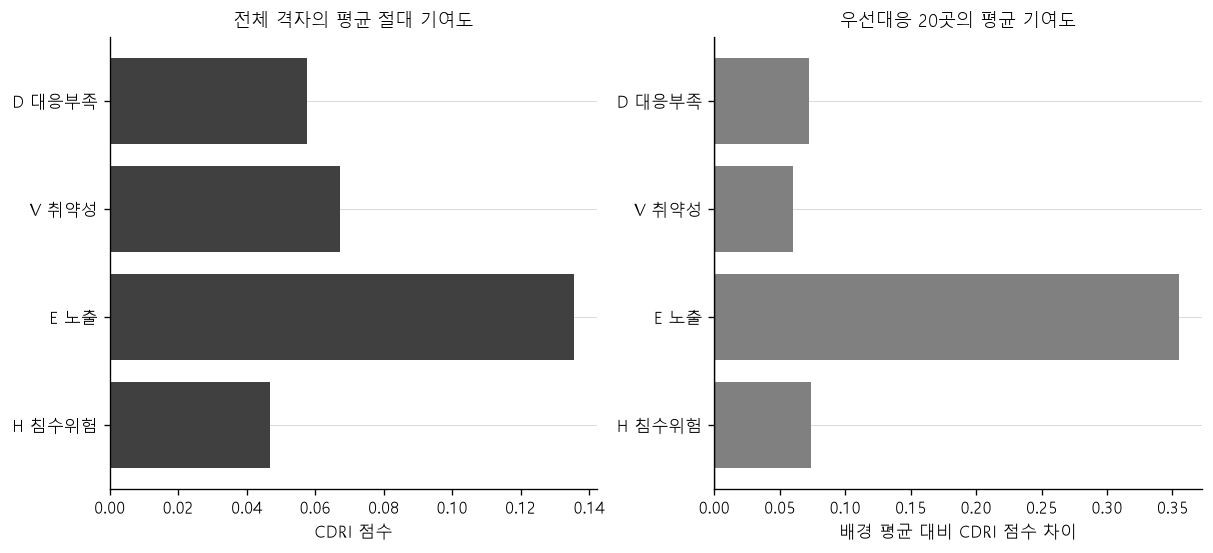

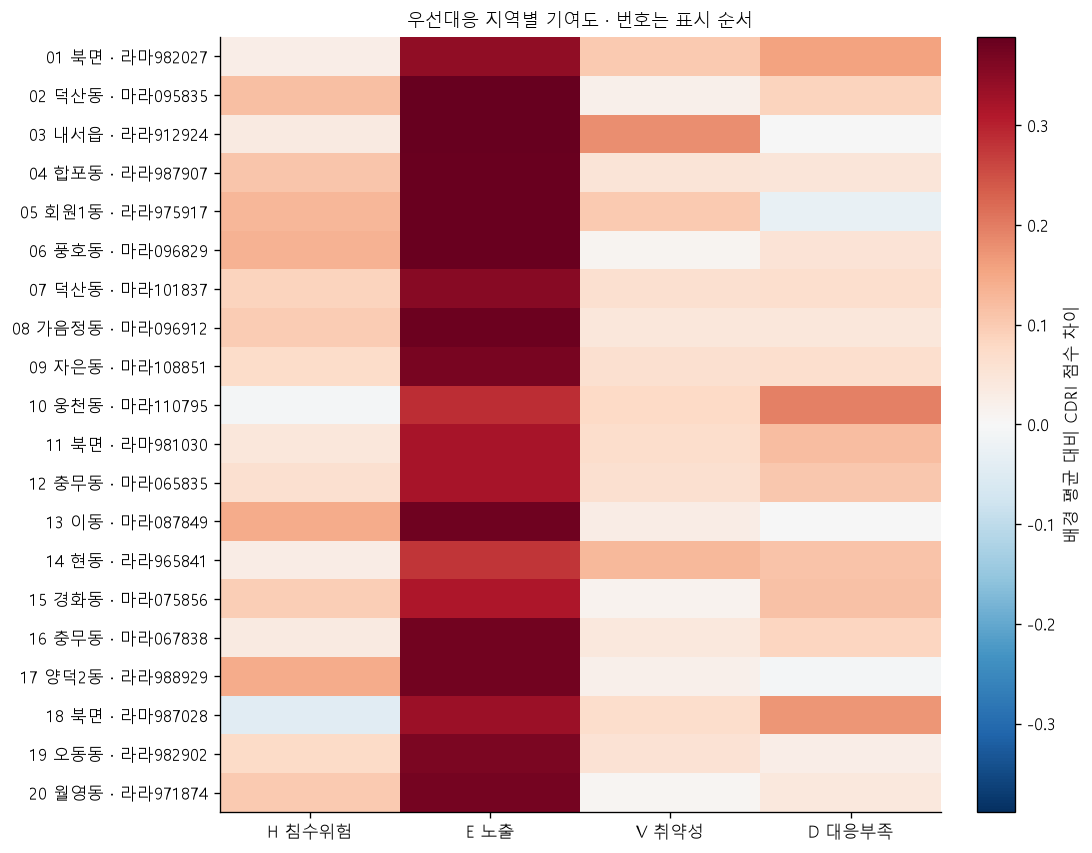

In [39]:
import matplotlib.pyplot as plt
from src.visualization import style

style.apply()
xai_labels = ["H 침수위험", "E 노출", "V 취약성", "D 대응부족"]
xai_figures = ROOT / "reports/figures/xai"
xai_figures.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")
axes[0].barh(xai_labels, xai_summary["mean_absolute_shap"], color=style.DARK)
axes[0].set_title("전체 격자의 평균 절대 기여도")
axes[0].set_xlabel("CDRI 점수")
axes[1].barh(xai_labels, xai_summary["top20_mean_shap"], color=style.MID)
axes[1].axvline(0, color=style.INK, linewidth=.8)
axes[1].set_title("우선대응 20곳의 평균 기여도")
axes[1].set_xlabel("배경 평균 대비 CDRI 점수 차이")
fig.savefig(xai_figures / "cdri_shap_summary.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
xai_limit = float(np.abs(xai_top[xai_columns].to_numpy()).max())
plot = ax.imshow(xai_top[xai_columns], cmap="RdBu_r", vmin=-xai_limit, vmax=xai_limit, aspect="auto")
ax.set_xticks(range(4), xai_labels)
ax.set_yticks(range(len(xai_top)), [
    f"{row['rank']:02d} {row['neighborhood']} · {row['grid_id']}" for _, row in xai_top.iterrows()
])
ax.set_title("우선대응 지역별 기여도 · 번호는 표시 순서")
ax.grid(False)
fig.colorbar(plot, ax=ax, label="배경 평균 대비 CDRI 점수 차이")
fig.savefig(xai_figures / "top20_shap.png")
plt.show()
plt.close(fig)

In [40]:
import hashlib

xai_evidence = {
    "method": "exact_interventional_shapley",
    "output": "fixed_minmax_cdri",
    "components": xai_components,
    "weights": xai_weights.tolist(),
    "background": "all_ranking_universe_grids",
    "n_background": len(cdri),
    "n_coalitions": 16,
    "baseline": xai_baseline,
    "output_bounds": xai_bounds,
    "max_reconstruction_error": float(np.abs(xai_reconstructed - cdri["cdri"]).max()),
    "source_run_id": xai_formula["run_id"],
    "source_sha256": {
        str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
        for path in (LAYERS / "cdri.gpkg", xai_formula_path, xai_top_source)
    },
    "limits": ["산식 기여도이며 인과효과·침수확률이 아님", "배경 선택과 요소 간 의존성에 민감"],
}
(ROOT / "artifacts/evaluation/cdri_xai.json").write_text(
    json.dumps(xai_evidence, ensure_ascii=False, indent=2), encoding="utf-8"
)
xai_evidence

{'method': 'exact_interventional_shapley',
 'output': 'fixed_minmax_cdri',
 'components': ['H', 'E', 'V', 'D'],
 'weights': [0.25, 0.25, 0.25, 0.25],
 'background': 'all_ranking_universe_grids',
 'n_background': 10202,
 'n_coalitions': 16,
 'baseline': 0.36916610738352446,
 'output_bounds': (0.10332819342389345, 0.5894126495462744),
 'max_reconstruction_error': 4.440892098500626e-16,
 'source_run_id': '20260916T150800Z-140a433-0fe4096d',
 'source_sha256': {'data/processed/layers/cdri.gpkg': '667fd3c1d0af88964decdc437fd1102eaaf33aedaa3a1c730d4a7ed1433bc0e9',
  'artifacts/evaluation/primary_formula_manifest.json': 'aae479e07011aa62874dff09f1c8c5894f90bfc6a1ca555bf3116f04036bf648',
  'reports/tables/top20.csv': 'cf3a6b6f1967d99b111adaa2b4457521a3c47ece4be066f461929c1dacd78241'},
 'limits': ['산식 기여도이며 인과효과·침수확률이 아님', '배경 선택과 요소 간 의존성에 민감']}

## 7. 다음 단계

05 노트북의 정책카드와 함께 `top20_xai.csv`를 확인한다. 산식과 등급의 기존 한계는 유지한다.